<a href="https://colab.research.google.com/github/vaishnaviikommidi007/MLProject/blob/main/Walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Walmart.csv to Walmart.csv


In [4]:
uploaded.keys()

dict_keys(['Walmart.csv'])

In [5]:
import pandas as pd

df = pd.read_csv('Walmart.csv')

In [6]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
df.shape

(6435, 8)

In [8]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [10]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [13]:
import numpy as np


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

ValueError: time data "19-02-2010" doesn't match format "%m-%d-%Y", at position 2. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [16]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [17]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [18]:
df['Date'].dtype

dtype('<M8[ns]')

In [19]:
print(df['Date'].min())
print(df['Date'].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [20]:
df = df.sort_values(['Store', 'Date'])

In [21]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

In [22]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [23]:
pd.to_datetime(df['Date'], format='%d-%m-%Y')

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
6430,2012-09-28
6431,2012-10-05
6432,2012-10-12
6433,2012-10-19


In [24]:
df['Date'].dtype

dtype('<M8[ns]')

In [25]:
df[['Store', 'Date', 'Weekly_Sales']].head()

,Store,Date,Weekly_Sales
0,1,2010-02-05,1643690.90
1,1,2010-02-12,1641957.44
2,1,2010-02-19,1611968.17
3,1,2010-02-26,1409727.59
4,1,2010-03-05,1554806.68


In [26]:
df = df.sort_values(['Store', 'Date'])

In [27]:
df = df.sort_values(['Store', 'Date'])

In [28]:
df = df.reset_index(drop=True)

In [29]:
df = df.reset_index(drop=True)

In [30]:
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,2
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808,2010,4,14,2


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df = df.drop_duplicates()

In [33]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

In [34]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [35]:
df.shape


(6435, 12)

In [36]:
df.columns


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week',
       'Quarter'],
      dtype='object')

In [37]:
df['Weekly_Sales'].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


In [38]:
df['Store'].nunique()

45

In [39]:
df['Store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [40]:
df['Store'].value_counts().sort_index()

,count
Store,
1,143
2,143
3,143
4,143
5,143
6,143
7,143
8,143
9,143


In [41]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2010-02-05 00:00:00
End Date: 2012-10-26 00:00:00


In [42]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean()

store_sales.sort_values(ascending=False).head(10)

,Weekly_Sales
Store,
20,2.107677e+06
4,2.094713e+06
14,2.020978e+06
13,2.003620e+06
2,1.925751e+06
10,1.899425e+06
27,1.775216e+06
6,1.564728e+06
1,1.555264e+06


In [43]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


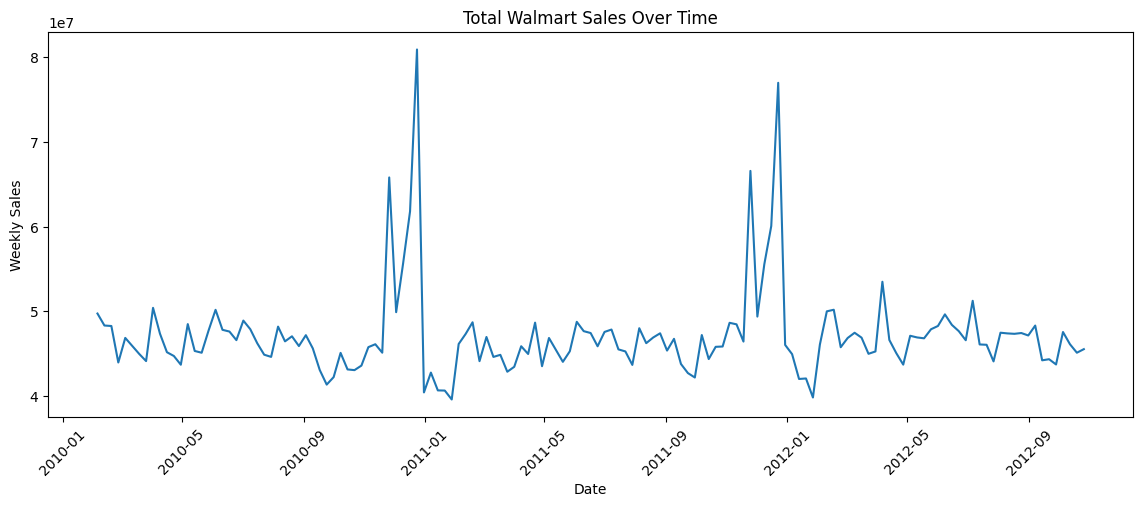

In [44]:
import matplotlib.pyplot as plt
total_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))

plt.plot(total_sales)

plt.title('Total Walmart Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)

plt.show()

In [45]:
numeric_cols = [
    'Weekly_Sales',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

corr = df[numeric_cols].corr()

corr

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,0.036891,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,0.036891,1.000000,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-0.063810,-0.155091,1.000000,0.144982,0.176888,0.101158
Fuel_Price,0.009464,-0.078347,0.144982,1.000000,-0.170642,-0.034684
CPI,-0.072634,-0.002162,0.176888,-0.170642,1.000000,-0.302020
Unemployment,-0.106176,0.010960,0.101158,-0.034684,-0.302020,1.000000


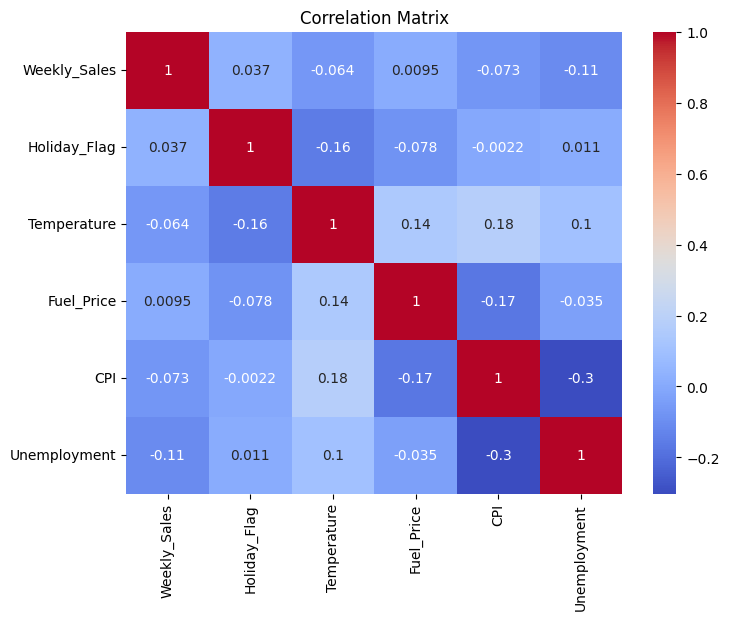

In [46]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

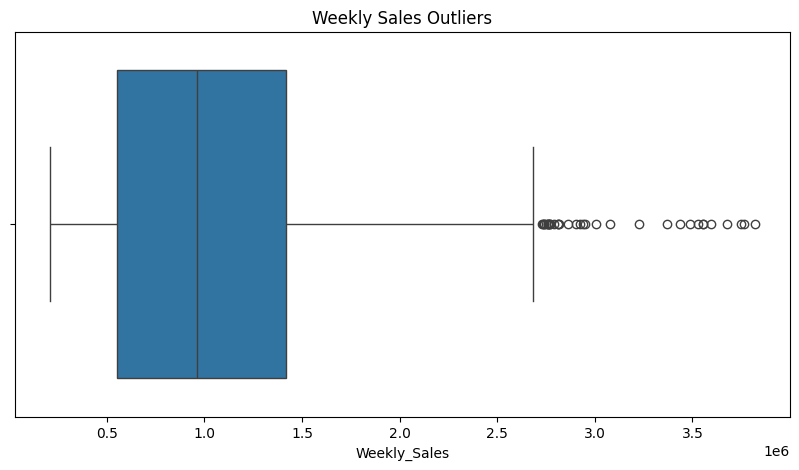

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Weekly_Sales'])

plt.title('Weekly Sales Outliers')

plt.show()

In [48]:
# Create useful features from Date

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [49]:
df[['Date', 'Year', 'Month', 'Week', 'Quarter']].head()

,Date,Year,Month,Week,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   int64         
 11  Quarter       6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(3)
memory usage: 528.0 KB


In [51]:
df = df.sort_values('Date').reset_index(drop=True)

In [52]:
print(df['Date'].min())
print(df['Date'].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


In [53]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("Train dates:", train['Date'].min(), "to", train['Date'].max())
print("Test dates:", test['Date'].min(), "to", test['Date'].max())

Training data: (5148, 12)
Testing data: (1287, 12)
Train dates: 2010-02-05 00:00:00 to 2012-04-13 00:00:00
Test dates: 2012-04-13 00:00:00 to 2012-10-26 00:00:00


In [54]:
X_train = train.drop(columns=['Weekly_Sales', 'Date'])
y_train = train['Weekly_Sales']

X_test = test.drop(columns=['Weekly_Sales', 'Date'])
y_test = test['Weekly_Sales']

In [55]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5148, 10)
y_train: (5148,)
X_test: (1287, 10)
y_test: (1287,)


In [56]:
print(X_train.columns.tolist())

['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter']


In [57]:
df.columns


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week',
       'Quarter'],
      dtype='object')

In [58]:
print("TRAIN DATE RANGE")
print("Start:", df.loc[X_train.index, "Date"].min())
print("End  :", df.loc[X_train.index, "Date"].max())

print("\nTEST DATE RANGE")
print("Start:", df.loc[X_test.index, "Date"].min())
print("End  :", df.loc[X_test.index, "Date"].max())

TRAIN DATE RANGE
Start: 2010-02-05 00:00:00
End  : 2012-04-13 00:00:00

TEST DATE RANGE
Start: 2012-04-13 00:00:00
End  : 2012-10-26 00:00:00


In [59]:
print(df.shape)
print(df.head())

(6435, 12)
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1     10 2010-02-05    2193048.75             0        54.34       2.962   
2     37 2010-02-05     536006.73             0        45.97       2.572   
3     17 2010-02-05     789036.02             0        23.11       2.666   
4     30 2010-02-05     465108.52             0        39.05       2.572   

          CPI  Unemployment  Year  Month  Week  Quarter  
0  211.096358         8.106  2010      2     5        1  
1  126.442065         9.765  2010      2     5        1  
2  209.852966         8.554  2010      2     5        1  
3  126.442065         6.548  2010      2     5        1  
4  210.752605         8.324  2010      2     5        1  


In [60]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   int64         
 11  Quarter       6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(3)
memory usage: 528.0 KB
None
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0

In [61]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [62]:
print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2010-02-05 00:00:00
Maximum date: 2012-10-26 00:00:00


In [63]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(df.head())

   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1      1 2010-02-12    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-03-05    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Year  Month  Week  Quarter  
0  211.096358         8.106  2010      2     5        1  
1  211.242170         8.106  2010      2     6        1  
2  211.289143         8.106  2010      2     7        1  
3  211.319643         8.106  2010      2     8        1  
4  211.350143         8.106  2010      3     9        1  


In [64]:
df["Lag_1"] = (
    df.groupby("Store")["Weekly_Sales"]
      .shift(1)
)

df["Lag_2"] = (
    df.groupby("Store")["Weekly_Sales"]
      .shift(2)
)

df["Lag_4"] = (
    df.groupby("Store")["Weekly_Sales"]
      .shift(4)
)

df["Lag_8"] = (
    df.groupby("Store")["Weekly_Sales"]
      .shift(8)
)

In [65]:
display(
    df[
        ["Store", "Date", "Weekly_Sales",
         "Lag_1", "Lag_2", "Lag_4", "Lag_8"]
    ].head(15)
)

,Store,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4,Lag_8
0,1,2010-02-05,1643690.90,NaN,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1643690.90,NaN,NaN,NaN
2,1,2010-02-19,1611968.17,1641957.44,1643690.90,NaN,NaN
3,1,2010-02-26,1409727.59,1611968.17,1641957.44,NaN,NaN
4,1,2010-03-05,1554806.68,1409727.59,1611968.17,1643690.90,NaN
5,1,2010-03-12,1439541.59,1554806.68,1409727.59,1641957.44,NaN
6,1,2010-03-19,1472515.79,1439541.59,1554806.68,1611968.17,NaN
7,1,2010-03-26,1404429.92,1472515.79,1439541.59,1409727.59,NaN
8,1,2010-04-02,1594968.28,1404429.92,1472515.79,1554806.68,1643690.90
9,1,2010-04-09,1545418.53,1594968.28,1404429.92,1439541.59,1641957.44


In [66]:
df["Rolling_Mean_4"] = (
    df.groupby("Store")["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)
df["Rolling_Mean_8"] = (
    df.groupby("Store")["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(8).mean())
)
df["Rolling_Mean_12"] = (
    df.groupby("Store")["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(12).mean())
)

In [67]:
print(df.columns.tolist())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_8', 'Rolling_Mean_4', 'Rolling_Mean_8', 'Rolling_Mean_12']


In [68]:
print(df.isnull().sum())

Store                0
Date                 0
Weekly_Sales         0
Holiday_Flag         0
Temperature          0
Fuel_Price           0
CPI                  0
Unemployment         0
Year                 0
Month                0
Week                 0
Quarter              0
Lag_1               45
Lag_2               90
Lag_4              180
Lag_8              360
Rolling_Mean_4     180
Rolling_Mean_8     360
Rolling_Mean_12    540
dtype: int64


In [69]:
df_model = df.dropna().copy()

print("Original shape:", df.shape)
print("Model shape:", df_model.shape)

Original shape: (6435, 19)
Model shape: (5895, 19)


In [70]:
unique_dates = sorted(df_model["Date"].unique())

split_index = int(len(unique_dates) * 0.80)

cutoff_date = unique_dates[split_index]

print("Cutoff date:", cutoff_date)

Cutoff date: 2012-04-27 00:00:00


In [71]:
train_df = df_model[df_model["Date"] < cutoff_date].copy()

test_df = df_model[df_model["Date"] >= cutoff_date].copy()

In [72]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTRAIN DATE RANGE")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTEST DATE RANGE")
print(test_df["Date"].min(), "to", test_df["Date"].max())

Train shape: (4680, 19)
Test shape : (1215, 19)

TRAIN DATE RANGE
2010-04-30 00:00:00 to 2012-04-20 00:00:00

TEST DATE RANGE
2012-04-27 00:00:00 to 2012-10-26 00:00:00


In [73]:
unique_dates = sorted(df_model["Date"].unique())

In [74]:
split_index = int(len(unique_dates) * 0.80)

In [75]:
cutoff_date = unique_dates[split_index]

In [76]:
train_df = df_model[df_model["Date"] < cutoff_date].copy()

In [77]:
test_df = df_model[df_model["Date"] >= cutoff_date].copy()

In [78]:
print("Train rows:", train_df.shape[0])
print("Train columns:", train_df.shape[1])

print("Test rows:", test_df.shape[0])
print("Test columns:", test_df.shape[1])

Train rows: 4680
Train columns: 19
Test rows: 1215
Test columns: 19


In [79]:
print("Total rows:", len(train_df) + len(test_df))
print("Original rows:", len(df_model))

Total rows: 5895
Original rows: 5895


In [80]:
print("Last training date:", train_df["Date"].max())
print("First testing date:", test_df["Date"].min())

Last training date: 2012-04-20 00:00:00
First testing date: 2012-04-27 00:00:00


In [81]:
print("Maximum train date:", train_df["Date"].max())
print("Minimum test date:", test_df["Date"].min())

print("Is train date < test date?",
      train_df["Date"].max() < test_df["Date"].min())

Maximum train date: 2012-04-20 00:00:00
Minimum test date: 2012-04-27 00:00:00
Is train date < test date? True


In [82]:
print("Train %:", len(train_df) / len(df_model) * 100)
print("Test %:", len(test_df) / len(df_model) * 100)

Train %: 79.38931297709924
Test %: 20.610687022900763


In [83]:
print("Total rows:", len(df_model))

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("Train %:", len(train_df) / len(df_model) * 100)
print("Test %:", len(test_df) / len(df_model) * 100)

print("Train dates:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test dates:", test_df["Date"].min(), "to", test_df["Date"].max())

Total rows: 5895
Train rows: 4680
Test rows: 1215
Train %: 79.38931297709924
Test %: 20.610687022900763
Train dates: 2010-04-30 00:00:00 to 2012-04-20 00:00:00
Test dates: 2012-04-27 00:00:00 to 2012-10-26 00:00:00


In [87]:
target = "Weekly_Sales"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4680, 18)
y_train: (4680,)
X_test: (1215, 18)
y_test: (1215,)


In [86]:
print(df_model.columns.tolist())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_8', 'Rolling_Mean_4', 'Rolling_Mean_8', 'Rolling_Mean_12']


In [88]:
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12"
]

In [89]:
X_train = train_df[features]
y_train = train_df["Weekly_Sales"]

X_test = test_df[features]
y_test = test_df["Weekly_Sales"]

In [90]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Store              0
Holiday_Flag       0
Temperature        0
Fuel_Price         0
CPI                0
Unemployment       0
Year               0
Month              0
Week               0
Quarter            0
Lag_1              0
Lag_2              0
Lag_4              0
Lag_8              0
Rolling_Mean_4     0
Rolling_Mean_8     0
Rolling_Mean_12    0
dtype: int64
Store              0
Holiday_Flag       0
Temperature        0
Fuel_Price         0
CPI                0
Unemployment       0
Year               0
Month              0
Week               0
Quarter            0
Lag_1              0
Lag_2              0
Lag_4              0
Lag_8              0
Rolling_Mean_4     0
Rolling_Mean_8     0
Rolling_Mean_12    0
dtype: int64


In [91]:
features = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12"
]

X_train = train_df[features]
y_train = train_df["Weekly_Sales"]

X_test = test_df[features]
y_test = test_df["Weekly_Sales"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4680, 17)
y_train: (4680,)
X_test: (1215, 17)
y_test: (1215,)


In [93]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression training completed!")
y_pred = model.predict(X_test)

print(y_pred[:10])
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression training completed!
[1576767.72563489 1643182.73690772 1592823.16522005 1545680.04357298
 1520799.64394441 1631429.46483605 1603616.97349247 1604370.58846667
 1574114.48850477 1553049.35344125]
MAE: 53896.20571048086
RMSE: 73786.97744264474
R2 Score: 0.9809127958370936


In [94]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAPE:", mape, "%")

MAPE: 5.903183604988433 %


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

print("Ridge Regression training completed!")
ridge_pred = ridge_model.predict(X_test_scaled)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_mape = np.mean(
    np.abs((y_test - ridge_pred) / y_test)
) * 100

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)
print("Ridge MAPE:", ridge_mape)

Ridge Regression training completed!
Ridge MAE: 53781.021078850805
Ridge RMSE: 73655.99986250338
Ridge R2: 0.9809804982164761
Ridge MAPE: 5.887864456400231


In [97]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

print("Lasso Regression training completed!")
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

lasso_mape = np.mean(
    np.abs((y_test - lasso_pred) / y_test)
) * 100

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R2:", lasso_r2)
print("Lasso MAPE:", lasso_mape)

Lasso Regression training completed!
Lasso MAE: 53895.237090738345
Lasso RMSE: 73785.78765429338
Lasso R2: 0.9809134113806723
Lasso MAPE: 5.9029765848315625


In [98]:
for feature, coef in zip(features, lasso_model.coef_):
    print(f"{feature}: {coef}")


Store: -2807.2415505365493
Holiday_Flag: 4445.494779023464
Temperature: -11438.236265234258
Fuel_Price: 28157.507898419983
CPI: 7782.787225644932
Unemployment: -1879.697070402819
Year: -20523.42118719003
Month: 169373.59275044393
Week: -86295.19135663075
Quarter: -32595.33186771763
Lag_1: 136537.6181359185
Lag_2: 73113.9740458173
Lag_4: 137351.4284099708
Lag_8: 61793.253087180165
Rolling_Mean_4: 119448.76990053267
Rolling_Mean_8: -387542.10425420443
Rolling_Mean_12: 418770.57553548267


In [99]:
zero_coefficients = np.sum(lasso_model.coef_ == 0)

print("Number of zero coefficients:", zero_coefficients)

Number of zero coefficients: 0


In [100]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    pred = ridge.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    ridge_results.append([alpha, mae, rmse, r2, mape])

print("Alpha | MAE | RMSE | R2 | MAPE")

for result in ridge_results:
    print(result)

Alpha | MAE | RMSE | R2 | MAPE
[0.01, 53894.81855594116, np.float64(73785.43099122784), 0.9809135959003467, np.float64(5.903004073200158)]
[0.1, 53882.76742637257, np.float64(73771.75117160822), 0.9809206724832961, np.float64(5.901427618385173)]
[1, 53781.021078850805, np.float64(73655.99986250338), 0.9809804982164761, np.float64(5.887864456400231)]
[10, 53588.930968034154, np.float64(73405.86809221159), 0.9811094572627277, np.float64(5.848275857552684)]
[100, 54774.59853889487, np.float64(74231.1385393041), 0.9806823131722894, np.float64(5.960288465187861)]


In [101]:
from sklearn.linear_model import Lasso

lasso_results = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    pred = lasso.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    lasso_results.append([alpha, mae, rmse, r2, mape])

print("Alpha | MAE | RMSE | R2 | MAPE")

for result in lasso_results:
    print(result)

Alpha | MAE | RMSE | R2 | MAPE
[0.01, 53896.19393876166, np.float64(73786.96299816109), 0.9809128033100866, np.float64(5.903181331091388)]
[0.1, 53896.100904813065, np.float64(73786.84828797547), 0.9809128626564557, np.float64(5.9031622704761215)]
[1, 53895.237090738345, np.float64(73785.78765429338), 0.9809134113806723, np.float64(5.9029765848315625)]
[10, 53875.840042989395, np.float64(73762.11018260958), 0.9809256589873244, np.float64(5.899941412168978)]
[100, 53868.897345682286, np.float64(73712.6057661873), 0.9809512533542224, np.float64(5.892250878740316)]


In [102]:
zero_features = [
    feature
    for feature, coef in zip(features, best_lasso.coef_)
    if coef == 0
]

print(zero_features)

NameError: name 'best_lasso' is not defined

In [103]:
from sklearn.linear_model import Lasso

best_lasso = Lasso(alpha=100, max_iter=10000)

best_lasso.fit(X_train_scaled, y_train)

print("Best Lasso model trained!")

Best Lasso model trained!


In [104]:
zero_features = [
    feature
    for feature, coef in zip(features, best_lasso.coef_)
    if coef == 0
]

print("Features removed by Lasso:")
print(zero_features)

print("Number of features removed:", len(zero_features))

Features removed by Lasso:
[]
Number of features removed: 0


In [105]:
for feature, coef in zip(features, best_lasso.coef_):
    print(f"{feature}: {coef:.2f}")

Store: -2786.02
Holiday_Flag: 3654.97
Temperature: -11085.00
Fuel_Price: 27530.66
CPI: 7478.17
Unemployment: -1795.23
Year: -19827.84
Month: 143822.03
Week: -60348.74
Quarter: -32712.53
Lag_1: 140470.53
Lag_2: 77018.73
Lag_4: 138089.04
Lag_8: 57665.89
Rolling_Mean_4: 91839.40
Rolling_Mean_8: -339809.16
Rolling_Mean_12: 394081.45


In [106]:
X_train_scaled
y_train

,Weekly_Sales
12,1425100.71
13,1603955.12
14,1494251.50
15,1399662.07
16,1432069.95
...,...
6403,791835.37
6404,777254.06
6405,899479.43
6406,781970.60


In [107]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

ridge_cv.fit(X_train_scaled, y_train)

print("Best Alpha:", ridge_cv.best_params_["alpha"])
print("Best CV MAE:", -ridge_cv.best_score_)

Best Alpha: 10
Best CV MAE: 96432.17427908446


In [108]:
best_alpha = ridge_cv.best_params_["alpha"]

final_ridge = Ridge(alpha=best_alpha)

final_ridge.fit(X_train_scaled, y_train)

final_ridge_pred = final_ridge.predict(X_test_scaled)

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, final_ridge_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, final_ridge_pred)
)

r2 = r2_score(y_test, final_ridge_pred)

mape = np.mean(
    np.abs((y_test - final_ridge_pred) / y_test)
) * 100

print("Final Ridge Results")
print("-------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)
print("MAPE :", mape)

Final Ridge Results
-------------------
MAE  : 53588.930968034154
RMSE : 73405.86809221159
R²   : 0.9811094572627277
MAPE : 5.848275857552684


In [110]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
X_train
y_train
rf_model.fit(X_train, y_train)

print("Random Forest model trained!")

Random Forest model trained!


In [111]:
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

rf_mape = np.mean(
    np.abs((y_test - rf_pred) / y_test)
) * 100

print("Random Forest Results")
print("---------------------")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("R²   :", rf_r2)
print("MAPE :", rf_mape)

Random Forest Results
---------------------
MAE  : 44138.14960806584
RMSE : 62600.357227470195
R²   : 0.9862615891233044
MAPE : 4.332415223684408


In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

n_estimators_list = [100, 200, 300]

for n in n_estimators_list:

    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    print(f"\nNumber of Trees: {n}")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("MAPE :", mape)


Number of Trees: 100
MAE  : 44138.14960806582
RMSE : 62600.35722747019
R²   : 0.9862615891233044
MAPE : 4.332415223684408

Number of Trees: 200
MAE  : 43767.43554806582
RMSE : 62240.438168609224
R²   : 0.986419112223051
MAPE : 4.282668805469086

Number of Trees: 300
MAE  : 43715.68700449927
RMSE : 62073.14064403824
R²   : 0.9864920228717134
MAPE : 4.282445970606666


In [113]:
max_depths = [10, 20, 30, None]

for depth in max_depths:

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    print(f"\nMax Depth: {depth}")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("MAPE :", mape)


Max Depth: 10
MAE  : 43619.463498934885
RMSE : 62147.020871535715
R²   : 0.9864598490099583
MAPE : 4.2757372312442525

Max Depth: 20
MAE  : 43767.18715369456
RMSE : 62151.76718191654
R²   : 0.9864577807462713
MAPE : 4.2826303121486555

Max Depth: 30
MAE  : 43739.82491382883
RMSE : 62071.47868948285
R²   : 0.9864927461907965
MAPE : 4.284162796676677

Max Depth: None
MAE  : 43715.68700449927
RMSE : 62073.14064403824
R²   : 0.9864920228717134
MAPE : 4.282445970606666


In [114]:
split_values = [2, 5, 10, 20]

for split in split_values:

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=split,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    print(f"\nMin Samples Split: {split}")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("MAPE :", mape)


Min Samples Split: 2
MAE  : 43739.82491382883
RMSE : 62071.47868948284
R²   : 0.9864927461907965
MAPE : 4.284162796676677

Min Samples Split: 5
MAE  : 43742.44420665101
RMSE : 62141.94566470823
R²   : 0.986462060419607
MAPE : 4.280706902242845

Min Samples Split: 10
MAE  : 43655.77134564458
RMSE : 62027.10237946536
R²   : 0.986512052572152
MAPE : 4.2721337207128425

Min Samples Split: 20
MAE  : 43613.544223813165
RMSE : 62064.57081256124
R²   : 0.9864957524428414
MAPE : 4.263401569489222


In [116]:
leaf_values = [1, 2, 4, 8,10,12,14]

for leaf in leaf_values:

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=20,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    print(f"\nMin Samples Leaf: {leaf}")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("MAPE :", mape)


Min Samples Leaf: 1
MAE  : 43613.544223813165
RMSE : 62064.57081256124
R²   : 0.9864957524428414
MAPE : 4.263401569489222

Min Samples Leaf: 2
MAE  : 43223.35549875512
RMSE : 61877.9299425946
R²   : 0.986576850393993
MAPE : 4.212192441042205

Min Samples Leaf: 4
MAE  : 42945.24582517168
RMSE : 61881.40244933843
R²   : 0.986575343773281
MAPE : 4.164390532094197

Min Samples Leaf: 8
MAE  : 42806.631972670126
RMSE : 61807.9908042666
R²   : 0.9866071769729341
MAPE : 4.1433247412490335

Min Samples Leaf: 10
MAE  : 42886.995729509836
RMSE : 61931.66578605247
R²   : 0.9865535264895561
MAPE : 4.14916128440139

Min Samples Leaf: 12
MAE  : 42889.33592101568
RMSE : 62072.99064478555
R²   : 0.986492088155474
MAPE : 4.15057881275247

Min Samples Leaf: 14
MAE  : 43072.59721540345
RMSE : 62492.62107772511
R²   : 0.9863088364522223
MAPE : 4.168540925784977


In [117]:
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_split=20,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

rf_final_pred = rf_final.predict(X_test)

print("Final Random Forest model trained!")
rf_mae = mean_absolute_error(y_test, rf_final_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_final_pred)
)

rf_r2 = r2_score(y_test, rf_final_pred)

rf_mape = np.mean(
    np.abs((y_test - rf_final_pred) / y_test)
) * 100

print("Final Random Forest Results")
print("---------------------------")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("R²   :", rf_r2)
print("MAPE :", rf_mape)

Final Random Forest model trained!
Final Random Forest Results
---------------------------
MAE  : 42806.63197267012
RMSE : 61807.990804266585
R²   : 0.9866071769729341
MAPE : 4.1433247412490335


In [118]:
feature_importance = rf_final.feature_importances_

for feature, importance in zip(features, feature_importance):
    print(f"{feature}: {importance:.4f}")

Store: 0.0004
Holiday_Flag: 0.0012
Temperature: 0.0007
Fuel_Price: 0.0004
CPI: 0.0006
Unemployment: 0.0004
Year: 0.0000
Month: 0.0010
Week: 0.0330
Quarter: 0.0000
Lag_1: 0.3494
Lag_2: 0.0037
Lag_4: 0.0253
Lag_8: 0.0024
Rolling_Mean_4: 0.4909
Rolling_Mean_8: 0.0281
Rolling_Mean_12: 0.0624


In [119]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_final.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

            Feature  Importance
14   Rolling_Mean_4    0.490918
10            Lag_1    0.349443
16  Rolling_Mean_12    0.062350
8              Week    0.032971
15   Rolling_Mean_8    0.028090
12            Lag_4    0.025311
11            Lag_2    0.003748
13            Lag_8    0.002431
1      Holiday_Flag    0.001225
7             Month    0.000969
2       Temperature    0.000661
4               CPI    0.000605
5      Unemployment    0.000427
3        Fuel_Price    0.000427
0             Store    0.000351
9           Quarter    0.000042
6              Year    0.000030


In [121]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
tscv = TimeSeriesSplit(n_splits=5)

In [122]:
rf_cv = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_split=20,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

cv_mae_scores = []

for fold, (train_index, val_index) in enumerate(tscv.split(X_train), 1):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]

    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    rf_cv.fit(X_train_fold, y_train_fold)

    val_pred = rf_cv.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, val_pred)

    cv_mae_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.2f}")

print("\nTime Series Cross-Validation Results")
print("------------------------------------")
print("Mean MAE:", np.mean(cv_mae_scores))
print("Std MAE :", np.std(cv_mae_scores))

Fold 1 MAE: 107626.37
Fold 2 MAE: 96549.07
Fold 3 MAE: 81730.43
Fold 4 MAE: 47408.88
Fold 5 MAE: 48533.58

Time Series Cross-Validation Results
------------------------------------
Mean MAE: 76369.66578487642
Std MAE : 24602.857509570036


In [123]:
print(X_train.index[:10])
print(X_train.index[-10:])

Index([12, 13, 14, 15, 16, 17, 18, 19, 20, 21], dtype='int64')
Index([6398, 6399, 6400, 6401, 6402, 6403, 6404, 6405, 6406, 6407], dtype='int64')


In [124]:
print(train_df["Date"].is_monotonic_increasing)

False


In [125]:
train_df = train_df.sort_values(["Date", "Store"]).reset_index(drop=True)

test_df = test_df.sort_values(["Date", "Store"]).reset_index(drop=True)

In [126]:
print(train_df["Date"].is_monotonic_increasing)

True


In [127]:
X_train = train_df[features]
y_train = train_df["Weekly_Sales"]

X_test = test_df[features]
y_test = test_df["Weekly_Sales"]

In [128]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4680, 17)
(4680,)
(1215, 17)
(1215,)


In [129]:
print(train_df[["Date", "Store"]].head(10))
print()
print(train_df[["Date", "Store"]].tail(10))

        Date  Store
0 2010-04-30      1
1 2010-04-30      2
2 2010-04-30      3
3 2010-04-30      4
4 2010-04-30      5
5 2010-04-30      6
6 2010-04-30      7
7 2010-04-30      8
8 2010-04-30      9
9 2010-04-30     10

           Date  Store
4670 2012-04-20     36
4671 2012-04-20     37
4672 2012-04-20     38
4673 2012-04-20     39
4674 2012-04-20     40
4675 2012-04-20     41
4676 2012-04-20     42
4677 2012-04-20     43
4678 2012-04-20     44
4679 2012-04-20     45


In [130]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

cv_mae_scores = []

for fold, (train_index, val_index) in enumerate(tscv.split(X_train), 1):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]

    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    rf_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=20,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_train_fold, y_train_fold)

    val_pred = rf_cv.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, val_pred)

    cv_mae_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.2f}")

print("\nTime Series Cross-Validation Results")
print("------------------------------------")
print("Mean MAE:", np.mean(cv_mae_scores))
print("Std MAE :", np.std(cv_mae_scores))

Fold 1 MAE: 119456.77
Fold 2 MAE: 138289.78
Fold 3 MAE: 43742.47
Fold 4 MAE: 80373.66
Fold 5 MAE: 70318.61

Time Series Cross-Validation Results
------------------------------------
Mean MAE: 90436.25751732306
Std MAE : 34112.858416638024


In [131]:
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, val_index) in enumerate(tscv.split(X_train), 1):

    train_dates = train_df.iloc[train_index]["Date"]
    val_dates = train_df.iloc[val_index]["Date"]

    print(f"\nFold {fold}")
    print("Training:", train_dates.min(), "to", train_dates.max())
    print("Validation:", val_dates.min(), "to", val_dates.max())


Fold 1
Training: 2010-04-30 00:00:00 to 2010-08-27 00:00:00
Validation: 2010-08-27 00:00:00 to 2010-12-24 00:00:00

Fold 2
Training: 2010-04-30 00:00:00 to 2010-12-24 00:00:00
Validation: 2010-12-24 00:00:00 to 2011-04-22 00:00:00

Fold 3
Training: 2010-04-30 00:00:00 to 2011-04-22 00:00:00
Validation: 2011-04-29 00:00:00 to 2011-08-26 00:00:00

Fold 4
Training: 2010-04-30 00:00:00 to 2011-08-26 00:00:00
Validation: 2011-08-26 00:00:00 to 2011-12-23 00:00:00

Fold 5
Training: 2010-04-30 00:00:00 to 2011-12-23 00:00:00
Validation: 2011-12-23 00:00:00 to 2012-04-20 00:00:00


In [134]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

unique_train_dates = np.sort(train_df["Date"].unique())

date_tscv = TimeSeriesSplit(n_splits=5)

cv_splits = []

for train_date_idx, val_date_idx in date_tscv.split(unique_train_dates):

    train_dates_fold = unique_train_dates[train_date_idx]
    val_dates_fold = unique_train_dates[val_date_idx]

    train_rows = np.where(
        train_df["Date"].isin(train_dates_fold)
    )[0]

    val_rows = np.where(
        train_df["Date"].isin(val_dates_fold)
    )[0]

    cv_splits.append((train_rows, val_rows))


In [135]:
for fold, (train_index, val_index) in enumerate(cv_splits, 1):

    train_dates = train_df.iloc[train_index]["Date"]
    val_dates = train_df.iloc[val_index]["Date"]

    print(f"\nFold {fold}")
    print("Training:", train_dates.min(), "to", train_dates.max())
    print("Validation:", val_dates.min(), "to", val_dates.max())

    print(
        "Overlap:",
        len(set(train_dates).intersection(set(val_dates)))
    )


Fold 1
Training: 2010-04-30 00:00:00 to 2010-09-03 00:00:00
Validation: 2010-09-10 00:00:00 to 2010-12-31 00:00:00
Overlap: 0

Fold 2
Training: 2010-04-30 00:00:00 to 2010-12-31 00:00:00
Validation: 2011-01-07 00:00:00 to 2011-04-29 00:00:00
Overlap: 0

Fold 3
Training: 2010-04-30 00:00:00 to 2011-04-29 00:00:00
Validation: 2011-05-06 00:00:00 to 2011-08-26 00:00:00
Overlap: 0

Fold 4
Training: 2010-04-30 00:00:00 to 2011-08-26 00:00:00
Validation: 2011-09-02 00:00:00 to 2011-12-23 00:00:00
Overlap: 0

Fold 5
Training: 2010-04-30 00:00:00 to 2011-12-23 00:00:00
Validation: 2011-12-30 00:00:00 to 2012-04-20 00:00:00
Overlap: 0


In [136]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

cv_mae_scores = []

for fold, (train_index, val_index) in enumerate(cv_splits, 1):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]

    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    rf_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=20,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_train_fold, y_train_fold)

    val_pred = rf_cv.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, val_pred)

    cv_mae_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.2f}")

print("\nTime Series Cross-Validation Results")
print("------------------------------------")
print(f"Mean MAE: {np.mean(cv_mae_scores):.2f}")
print(f"Std MAE : {np.std(cv_mae_scores):.2f}")

Fold 1 MAE: 146894.00
Fold 2 MAE: 105118.26
Fold 3 MAE: 43104.51
Fold 4 MAE: 81380.27
Fold 5 MAE: 70066.34

Time Series Cross-Validation Results
------------------------------------
Mean MAE: 89312.68
Std MAE : 35025.60


In [137]:
df_check = df_model.sort_values(["Store", "Date"]).copy()

df_check["Lag_1_check"] = (
    df_check.groupby("Store")["Weekly_Sales"]
    .shift(1)
)

df_check["Rolling_Mean_4_check"] = (
    df_check.groupby("Store")["Weekly_Sales"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

print(
    "Lag_1 difference:",
    (df_check["Lag_1"] - df_check["Lag_1_check"]).abs().max()
)

print(
    "Rolling_Mean_4 difference:",
    (df_check["Rolling_Mean_4"] - df_check["Rolling_Mean_4_check"]).abs().max()
)

Lag_1 difference: 0.0
Rolling_Mean_4 difference: 4.656612873077393e-10


In [138]:
for fold, (train_index, val_index) in enumerate(cv_splits, 1):

    y_val_fold = y_train.iloc[val_index]

    print(f"\nFold {fold}")

    print(
        "Validation dates:",
        train_df.iloc[val_index]["Date"].min(),
        "to",
        train_df.iloc[val_index]["Date"].max()
    )

    print("Mean sales:", y_val_fold.mean())
    print("Median sales:", y_val_fold.median())
    print("Min sales:", y_val_fold.min())
    print("Max sales:", y_val_fold.max())



Fold 1
Validation dates: 2010-09-10 00:00:00 to 2010-12-31 00:00:00
Mean sales: 1096535.1184836603
Median sales: 972405.38
Min sales: 209986.25
Max sales: 3818686.45

Fold 2
Validation dates: 2011-01-07 00:00:00 to 2011-04-29 00:00:00
Mean sales: 988128.4365490197
Median sales: 904261.65
Min sales: 231155.9
Max sales: 2351143.07

Fold 3
Validation dates: 2011-05-06 00:00:00 to 2011-08-26 00:00:00
Mean sales: 1032591.2084575164
Median sales: 953252.14
Min sales: 224806.96
Max sales: 2273470.62

Fold 4
Validation dates: 2011-09-02 00:00:00 to 2011-12-23 00:00:00
Mean sales: 1119355.5789281046
Median sales: 993436.67
Min sales: 220060.35
Max sales: 3676388.98

Fold 5
Validation dates: 2011-12-30 00:00:00 to 2012-04-20 00:00:00
Mean sales: 1024463.0977647059
Median sales: 937522.77
Min sales: 215359.21
Max sales: 2565259.92


In [139]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for fold, (train_index, val_index) in enumerate(cv_splits, 1):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]

    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    rf_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=30,
        min_samples_split=20,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_train_fold, y_train_fold)

    val_pred = rf_cv.predict(X_val_fold)

    mae = mean_absolute_error(y_val_fold, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, val_pred))
    r2 = r2_score(y_val_fold, val_pred)

    print(f"\nFold {fold}")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")


Fold 1
MAE  : 146,894.00
RMSE : 273,510.61
R²   : 0.8196

Fold 2
MAE  : 105,118.26
RMSE : 175,339.50
R²   : 0.8866

Fold 3
MAE  : 43,104.51
RMSE : 62,603.68
R²   : 0.9863

Fold 4
MAE  : 81,380.27
RMSE : 134,083.38
R²   : 0.9562

Fold 5
MAE  : 70,066.34
RMSE : 101,518.43
R²   : 0.9646


In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [20, 30],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [4, 8]
}

In [141]:
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv_splits,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=[(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108...
       4652, 4653, 4654, 4655, 4656, 4657, 4658, 4659, 4660, 4661, 4662,
       4663, 4664, 4665, 4666, 4667, 4668, 4669, 4670, 4671, 4672, 4673,
       4674, 4675, 4676, 4677, 4678, 4679]))],
             estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [20, 30], 'min_samples_leaf': [4, 8],
                         'min_samples_split': [10, 20],
                         'n_estimators': [200, 300]},
             scoring='neg_mean_absolute_error', verbose=1)

In [142]:
print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV MAE:")
print(-rf_grid.best_score_)

Best parameters:
{'max_depth': 20, 'min_samples_leaf': 8, 'min_samples_split': 10, 'n_estimators': 300}

Best CV MAE:
88778.65104352604


In [144]:
from sklearn.ensemble import RandomForestRegressor

rf_best = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)

print("Best Random Forest trained successfully!")
rf_best = rf_grid.best_estimator_

rf_best.fit(X_train, y_train)

print("Best Random Forest trained successfully!")

Best Random Forest trained successfully!
Best Random Forest trained successfully!


In [145]:
rf_test_pred = rf_best.predict(X_test)

print(rf_test_pred[:10])

[1624898.49902385 1897377.13786727  439341.51012851 2142010.92988831
  342837.17636516 1536952.57706714  491189.931322    918712.02103971
  580174.98620906 1892707.36705835]


In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_test_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

r2 = r2_score(y_test, rf_test_pred)

mape = np.mean(
    np.abs((y_test - rf_test_pred) / y_test)
) * 100

print("Final Random Forest Test Results")
print("--------------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)
print("MAPE :", mape, "%")

Final Random Forest Test Results
--------------------------------
MAE  : 42558.168585301246
RMSE : 61443.08922941672
R²   : 0.9867648470751118
MAPE : 4.127138506792747 %


In [147]:
pip install xgboost

In [148]:
from xgboost import XGBRegressor

In [149]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

xgb_mape = np.mean(
    np.abs((y_test - xgb_pred) / y_test)
) * 100

print("XGBoost Baseline Results")
print("------------------------")
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R²   :", xgb_r2)
print("MAPE :", xgb_mape, "%")

XGBoost Baseline Results
------------------------
MAE  : 37344.1236255144
RMSE : 54658.7611893918
R²   : 0.9895262441361284
MAPE : 3.657638548010996 %


In [151]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
    "min_child_weight": [3, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=cv_splits,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest CV MAE:")
print(-xgb_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}

Best CV MAE:
81221.56573300653


In [152]:
best_xgb = xgb_grid.best_estimator_

print(best_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


In [153]:
best_xgb.fit(X_train, y_train)

print("Best XGBoost model trained successfully!")

Best XGBoost model trained successfully!


In [154]:
xgb_final_pred = best_xgb.predict(X_test)

In [155]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_final_mae = mean_absolute_error(y_test, xgb_final_pred)

xgb_final_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_final_pred)
)

xgb_final_r2 = r2_score(y_test, xgb_final_pred)

xgb_final_mape = np.mean(
    np.abs((y_test - xgb_final_pred) / y_test)
) * 100

print("Final Tuned XGBoost Results")
print("---------------------------")
print("MAE  :", xgb_final_mae)
print("RMSE :", xgb_final_rmse)
print("R²   :", xgb_final_r2)
print("MAPE :", xgb_final_mape, "%")

Final Tuned XGBoost Results
---------------------------
MAE  : 37051.19168364197
RMSE : 54212.55301596175
R²   : 0.9896965516716206
MAPE : 3.6326926119560037 %


In [156]:
pip install lightgbm

In [157]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgb_mae = mean_absolute_error(y_test, lgb_pred)

lgb_rmse = np.sqrt(
    mean_squared_error(y_test, lgb_pred)
)

lgb_r2 = r2_score(y_test, lgb_pred)

lgb_mape = np.mean(
    np.abs((y_test - lgb_pred) / y_test)
) * 100

print("LightGBM Baseline Results")
print("-------------------------")
print("MAE  :", lgb_mae)
print("RMSE :", lgb_rmse)
print("R²   :", lgb_r2)
print("MAPE :", lgb_mape, "%")

LightGBM Baseline Results
-------------------------
MAE  : 38232.86202372694
RMSE : 55847.809888645446
R²   : 0.9890655946158456
MAPE : 3.7413552517653805 %


In [159]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

param_grid_lgb = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 40]
}

lgb_grid = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid_lgb,
    cv=cv_splits,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

lgb_grid.fit(X_train, y_train)

print("Best LightGBM parameters:")
print(lgb_grid.best_params_)

print("\nBest CV MAE:")
print(-lgb_grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best LightGBM parameters:
{'learning_rate': 0.03, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}

Best CV MAE:
82211.93849663912


In [160]:
best_lgb = lgb_grid.best_estimator_

best_lgb.fit(X_train, y_train)

lgb_final_pred = best_lgb.predict(X_test)

In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgb_final_mae = mean_absolute_error(y_test, lgb_final_pred)

lgb_final_rmse = np.sqrt(
    mean_squared_error(y_test, lgb_final_pred)
)

lgb_final_r2 = r2_score(y_test, lgb_final_pred)

lgb_final_mape = np.mean(
    np.abs((y_test - lgb_final_pred) / y_test)
) * 100

print("Final Tuned LightGBM Results")
print("----------------------------")
print("MAE  :", lgb_final_mae)
print("RMSE :", lgb_final_rmse)
print("R²   :", lgb_final_r2)
print("MAPE :", lgb_final_mape, "%")

Final Tuned LightGBM Results
----------------------------
MAE  : 38801.836438902115
RMSE : 56362.223256860954
R²   : 0.9888632336169145
MAPE : 3.7957097631476353 %
